In [ ]:
# ==========================================================
# ULTRA-FAST HIGH-ACCURACY LIGHTGBM (< 3 MINUTE RUNTIME)
# train.csv + test.csv + sample_submission.csv
# ==========================================================

# ============================
# 1. Import Libraries
# ============================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import accuracy_score

# Machine Learning & Preprocessing
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Set aesthetic styling for plots
sns.set_theme(style="whitegrid", palette="muted")

# ============================
# 2. Load Data
# ============================

KAGGLE_DATASET_URL = "/kaggle/input/competitions/playground-series-s6e8/"


def find_data_dir() -> Path:
    candidates = []
    cwd = Path.cwd().resolve()
    candidates.extend([
        cwd,
        cwd / "notebook",
        cwd.parent,
        cwd.parent / "notebook",
    ])

    for base in candidates:
        for candidate in [base / "input", base.parent / "input"]:
            if candidate.exists() and (candidate / "train.csv").exists() and (candidate / "test.csv").exists():
                return candidate

    for kaggle_path in [
        Path(KAGGLE_DATASET_URL),
        Path("/kaggle/input/train.csv").parent,
    ]:
        if kaggle_path.exists() and (kaggle_path / "train.csv").exists() and (kaggle_path / "test.csv").exists():
            return kaggle_path

    return Path(KAGGLE_DATASET_URL)


data_dir = find_data_dir()

train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")
sample_submission = pd.read_csv(data_dir / "sample_submission.csv")

# ============================
# 3. Separate X and y
# ============================
TARGET = "addicted_label"
X = train.drop(columns=[TARGET])
y = train[TARGET]
X_test = test.copy()


In [ ]:
# Load datasets
sample_sub = sample_submission.copy()

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample Submission shape: {sample_sub.shape}")

# Display the first few rows of the training set
display(train.head())

Train shape: (691369, 14)
Test shape: (296302, 13)
Sample Submission shape: (296302, 2)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


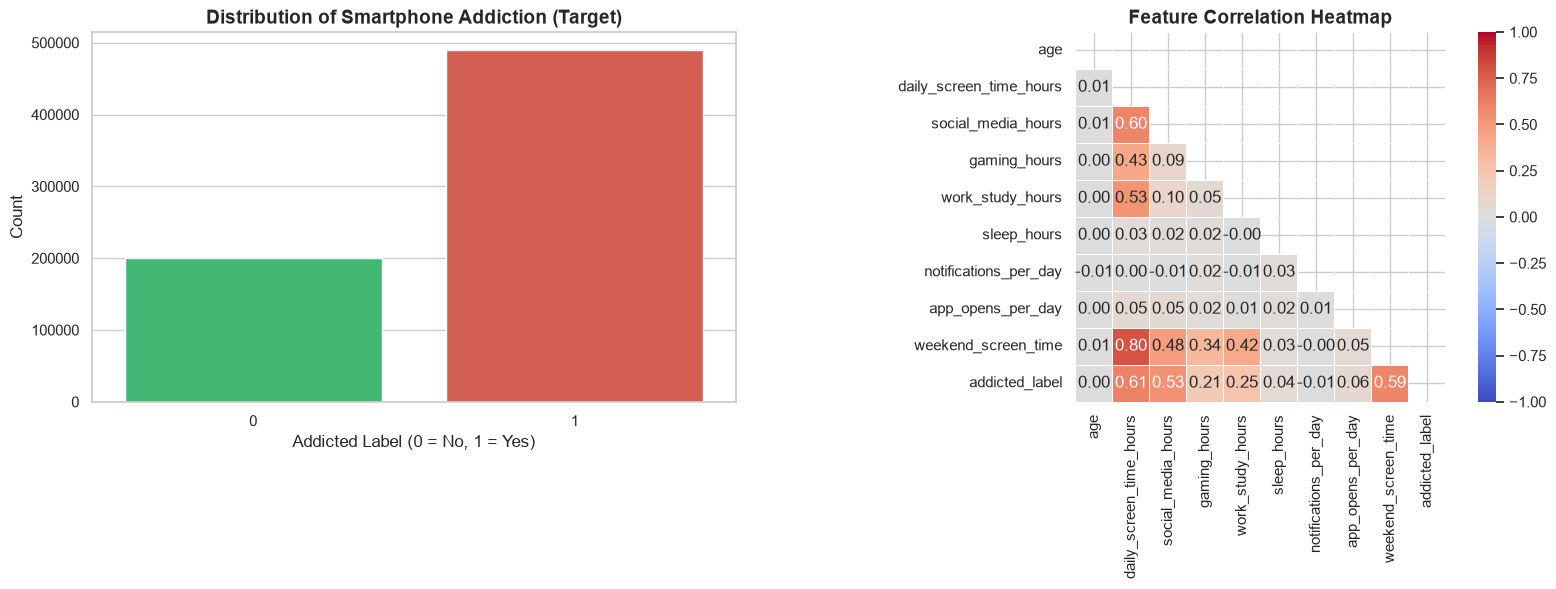

In [11]:
# Set up the matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Target Distribution
sns.countplot(data=train, x='addicted_label', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution of Smartphone Addiction (Target)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Addicted Label (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

# Plot 2: Correlation Heatmap
# Select only numerical columns for correlation
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns
# Drop 'id' as it has no predictive power
corr_cols = [col for col in numerical_cols if col != 'id'] 
corr_matrix = train[corr_cols].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Separate features and target
X = train.drop(columns=['id', 'addicted_label'])
y = train['addicted_label']
X_test = test.drop(columns=['id'])

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Apply Label Encoding to categorical features
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on train and test combined to avoid unseen categories
    le.fit(pd.concat([X[col], X_test[col]], axis=0).astype(str))
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

print("Data preprocessing complete. Categorical columns encoded.")

Data preprocessing complete. Categorical columns encoded.


In [ ]:
# Setup Stratified K-Fold
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

# Arrays to store out-of-fold predictions and test predictions
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
best_model = None
best_fold_auc = -np.inf

# LightGBM parameters (tuned for general tabular data)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'n_estimators': 600,# 1000
    'random_state': 42,
    'n_jobs': -1
}

print("Starting LightGBM Training...\n")

In [13]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    # Split data into train and validation for this fold
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_valid, y_valid = X.iloc[valid_idx], y.iloc[valid_idx]
    
    # Initialize and fit the model
    model = lgb.LGBMClassifier(**lgb_params)
    
    # Use early stopping to prevent overfitting
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    # Predict probabilities for validation set (Class 1)
    valid_probs = model.predict_proba(X_valid)[:, 1]
    oof_preds[valid_idx] = valid_probs
    
    # Calculate fold AUC
    fold_auc = roc_auc_score(y_valid, valid_probs)
    print(f"Fold {fold + 1} | ROC AUC: {fold_auc:.5f}")
    if fold_auc > best_fold_auc:
        best_fold_auc = fold_auc
        best_model = model
    
    # Predict probabilities for the test set and average them
    test_preds += model.predict_proba(X_test)[:, 1] / FOLDS
    print(" ")



Starting LightGBM Training...

[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.096202 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1958
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589
Fold 1 | ROC AUC: 0.95904
[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.169961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[Light

In [ ]:
# Calculate overall Out-Of-Fold AUC
oof_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF ROC AUC: {oof_auc:.5f}") # 0.95996 ---> 0.96128

final_accuracy = accuracy_score(y, (oof_preds >= 0.5).astype(int))
print(best_model, final_accuracy)


Overall OOF ROC AUC: 0.95996
LGBMClassifier(learning_rate=0.05, max_depth=6, metric='auc', n_estimators=600,
               n_jobs=-1, objective='binary', random_state=42) 0.8962594504526527


In [ ]:
# Create submission dataframe
submission = pd.DataFrame({
    'id': test['id'],
    'addicted_label': test_preds
})

# Save to Parquet
submission.to_parquet("submission.parquet", index=False)

# Display the first few rows of the submission file
display(submission.head())
print("\nsubmission.parquet successfully saved!")

,id,addicted_label
0,691369,0.998747
1,691370,0.956195
2,691371,0.959014
3,691372,0.983698
4,691373,0.996773



submission.parquet successfully saved!
